In [130]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

In [2]:
# Step 1 #
meg_folder = '/Users/snavil/PycharmProjects/Programming Geoinformatics/Session_5/meghalaya'
NE_folder = '/Users/snavil/PycharmProjects/Programming Geoinformatics/Session_5/NE_states'
meg_shp_path = os.path.join(meg_folder, 'meghalaya.shp')
NE_shp_path = os.path.join(NE_folder, 'NE_states.shp')
meg_gdf = gpd.read_file(meg_shp_path)
NE_gdf = gpd.read_file(NE_shp_path)
print(f'Meghalaya Projection: {meg_gdf.crs}')
print(f'NE Projection: {NE_gdf.crs}')

Meghalaya Projection: EPSG:3857
NE Projection: EPSG:3857


In [8]:
# Step 2 #
print(meg_gdf[meg_gdf.columns].isnull().sum())
print(NE_gdf[NE_gdf.columns].isnull().sum())

State_Name    0
geometry      0
dtype: int64
State_Name    0
geometry      0
dtype: int64


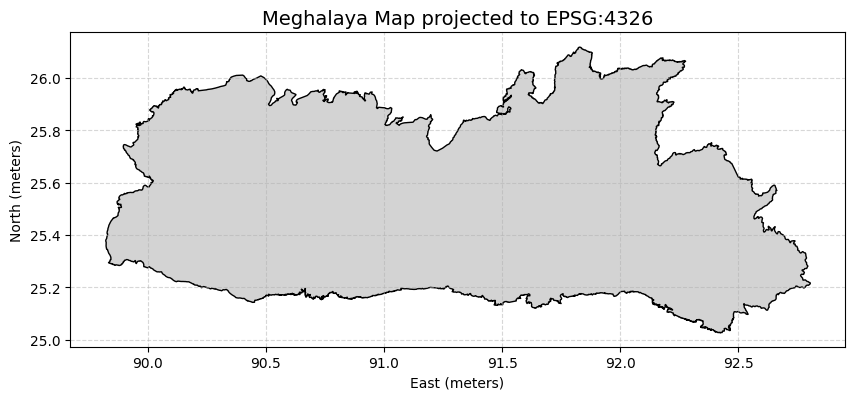

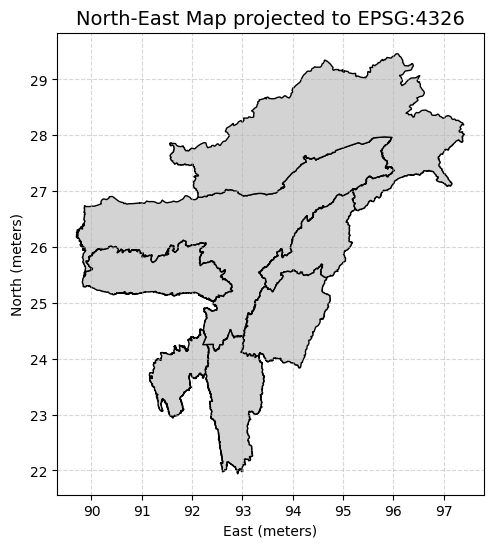

In [9]:
# Step 3 #
meg_new_gdf = meg_gdf.to_crs('EPSG:4326')
NE_new_gdf = NE_gdf.to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(10, 6))
meg_new_gdf.plot(ax=ax, color='lightgray', edgecolor='black')
ax.set_title("Meghalaya Map projected to EPSG:4326", fontsize=14)
ax.set_xlabel("East (meters)")
ax.set_ylabel("North (meters)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()
meg_new_gdf.to_file('/Users/snavil/PycharmProjects/Programming Geoinformatics/Session_5/meghalaya/Meghalaya_Reprojected.shp', driver='ESRI Shapefile')

fig, ax = plt.subplots(figsize=(10, 6))
NE_new_gdf.plot(ax=ax, color='lightgray', edgecolor='black')
ax.set_title("North-East Map projected to EPSG:4326", fontsize=14)
ax.set_xlabel("East (meters)")
ax.set_ylabel("North (meters)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()
NE_new_gdf.to_file('/Users/snavil/PycharmProjects/Programming Geoinformatics/Session_5/NE_states/NE_Reprojected.shp', driver='ESRI Shapefile')

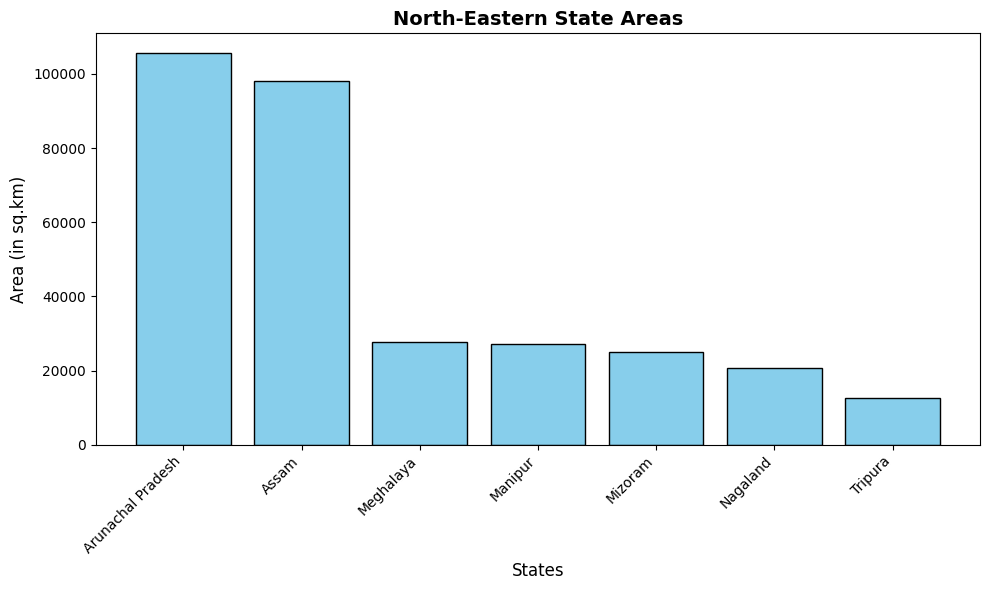

,State_Name,geometry,Area (in sq.km)
1,Arunachal Pradesh,"POLYGON ((10696175.277 3434232.65, 10696981.87...",105686.083492
0,Assam,"POLYGON ((10380499.251 2872443.723, 10380499.2...",98134.590488
6,Meghalaya,"POLYGON ((10222042.434 3013858.327, 10222165.9...",27649.319403
3,Manipur,"POLYGON ((10527945.945 2960789.34, 10528432.78...",27179.632682
4,Mizoram,"POLYGON ((10326423.582 2817021.246, 10326465.4...",25113.952104
2,Nagaland,"POLYGON ((10596805.532 3126858.281, 10597031.2...",20644.435936
5,Tripura,"POLYGON ((10260260.337 2818339.599, 10260273.8...",12527.445162


In [31]:
# Step 4 #
NE_df = gpd.read_file('/Users/snavil/PycharmProjects/Programming Geoinformatics/Session_5/NE_states/NE_states.dbf')
NE_df['Area (in sq.km)'] = NE_gdf.geometry.area / 10**6
NE_df.sort_values(by='Area (in sq.km)', ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
plt.bar(NE_df["State_Name"], NE_df["Area (in sq.km)"], color="skyblue", edgecolor="black")
plt.title("North-Eastern State Areas", fontsize=14, fontweight="bold")
plt.xlabel("States", fontsize=12)
plt.ylabel("Area (in sq.km)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

NE_df

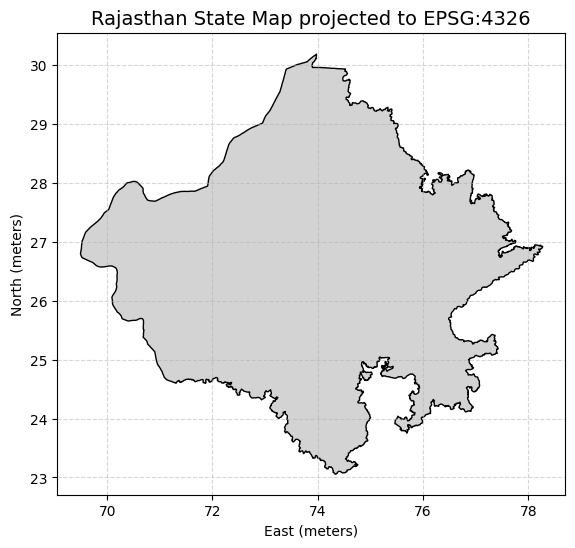

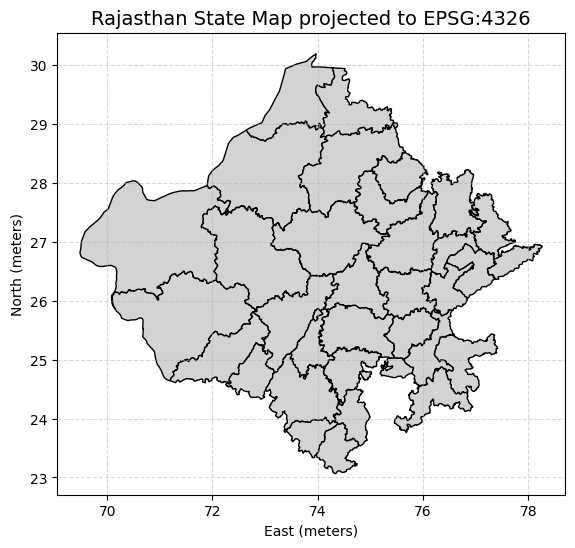

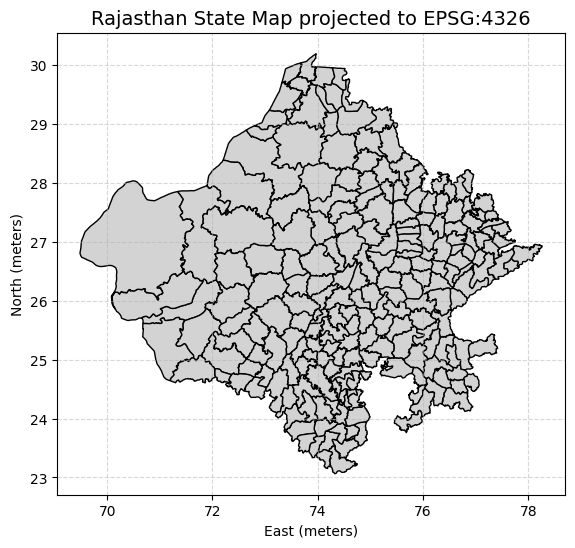

In [164]:
# Step 5 #
data_1 = gpd.read_file('/Users/snavil/PycharmProjects/Programming Geoinformatics/Session_5/gadm41_IND_shp/gadm41_IND_1.shp')
data_2 = gpd.read_file('/Users/snavil/PycharmProjects/Programming Geoinformatics/Session_5/gadm41_IND_shp/gadm41_IND_2.shp')
data_3 = gpd.read_file('/Users/snavil/PycharmProjects/Programming Geoinformatics/Session_5/gadm41_IND_shp/gadm41_IND_3.shp')
raj_1 = data_1[data_1['NAME_1'] == 'Rajasthan']
raj_2 = data_2[data_2['NAME_1'] == 'Rajasthan']
raj_3 = data_3[data_3['NAME_1'] == 'Rajasthan']

fig, ax = plt.subplots(figsize=(10, 6))
raj_1.plot(ax=ax, color='lightgray', edgecolor='black')
ax.set_title("Rajasthan State Map projected to EPSG:4326", fontsize=14)
ax.set_xlabel("East (meters)")
ax.set_ylabel("North (meters)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()
fig, ax = plt.subplots(figsize=(10, 6))
raj_2.plot(ax=ax, color='lightgray', edgecolor='black')
ax.set_title("Rajasthan State Map projected to EPSG:4326", fontsize=14)
ax.set_xlabel("East (meters)")
ax.set_ylabel("North (meters)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()
fig, ax = plt.subplots(figsize=(10, 6))
raj_3.plot(ax=ax, color='lightgray', edgecolor='black')
ax.set_title("Rajasthan State Map projected to EPSG:4326", fontsize=14)
ax.set_xlabel("East (meters)")
ax.set_ylabel("North (meters)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

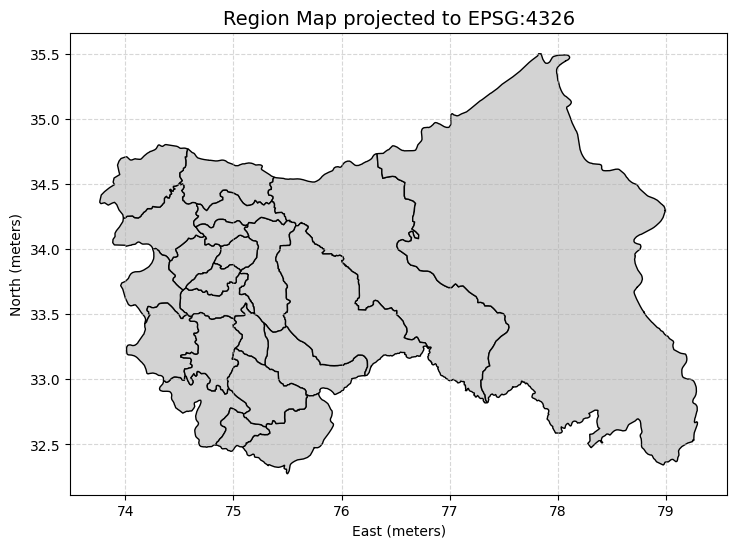

In [107]:
# Step 6 #
region = data_3[data_3['GID_0'] == 'Z01']
region_reprojected = region.to_crs('EPSG:4326')
region_reprojected.to_file('/Users/snavil/PycharmProjects/Programming Geoinformatics/Session_5/gadm41_IND_shp/Region_Reprojected.shp', driver='ESRI Shapefile')
fig, ax = plt.subplots(figsize=(10, 6))
z.plot(ax=ax, color='lightgray', edgecolor='black')
ax.set_title("Region Map projected to EPSG:4326", fontsize=14)
ax.set_xlabel("East (meters)")
ax.set_ylabel("North (meters)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

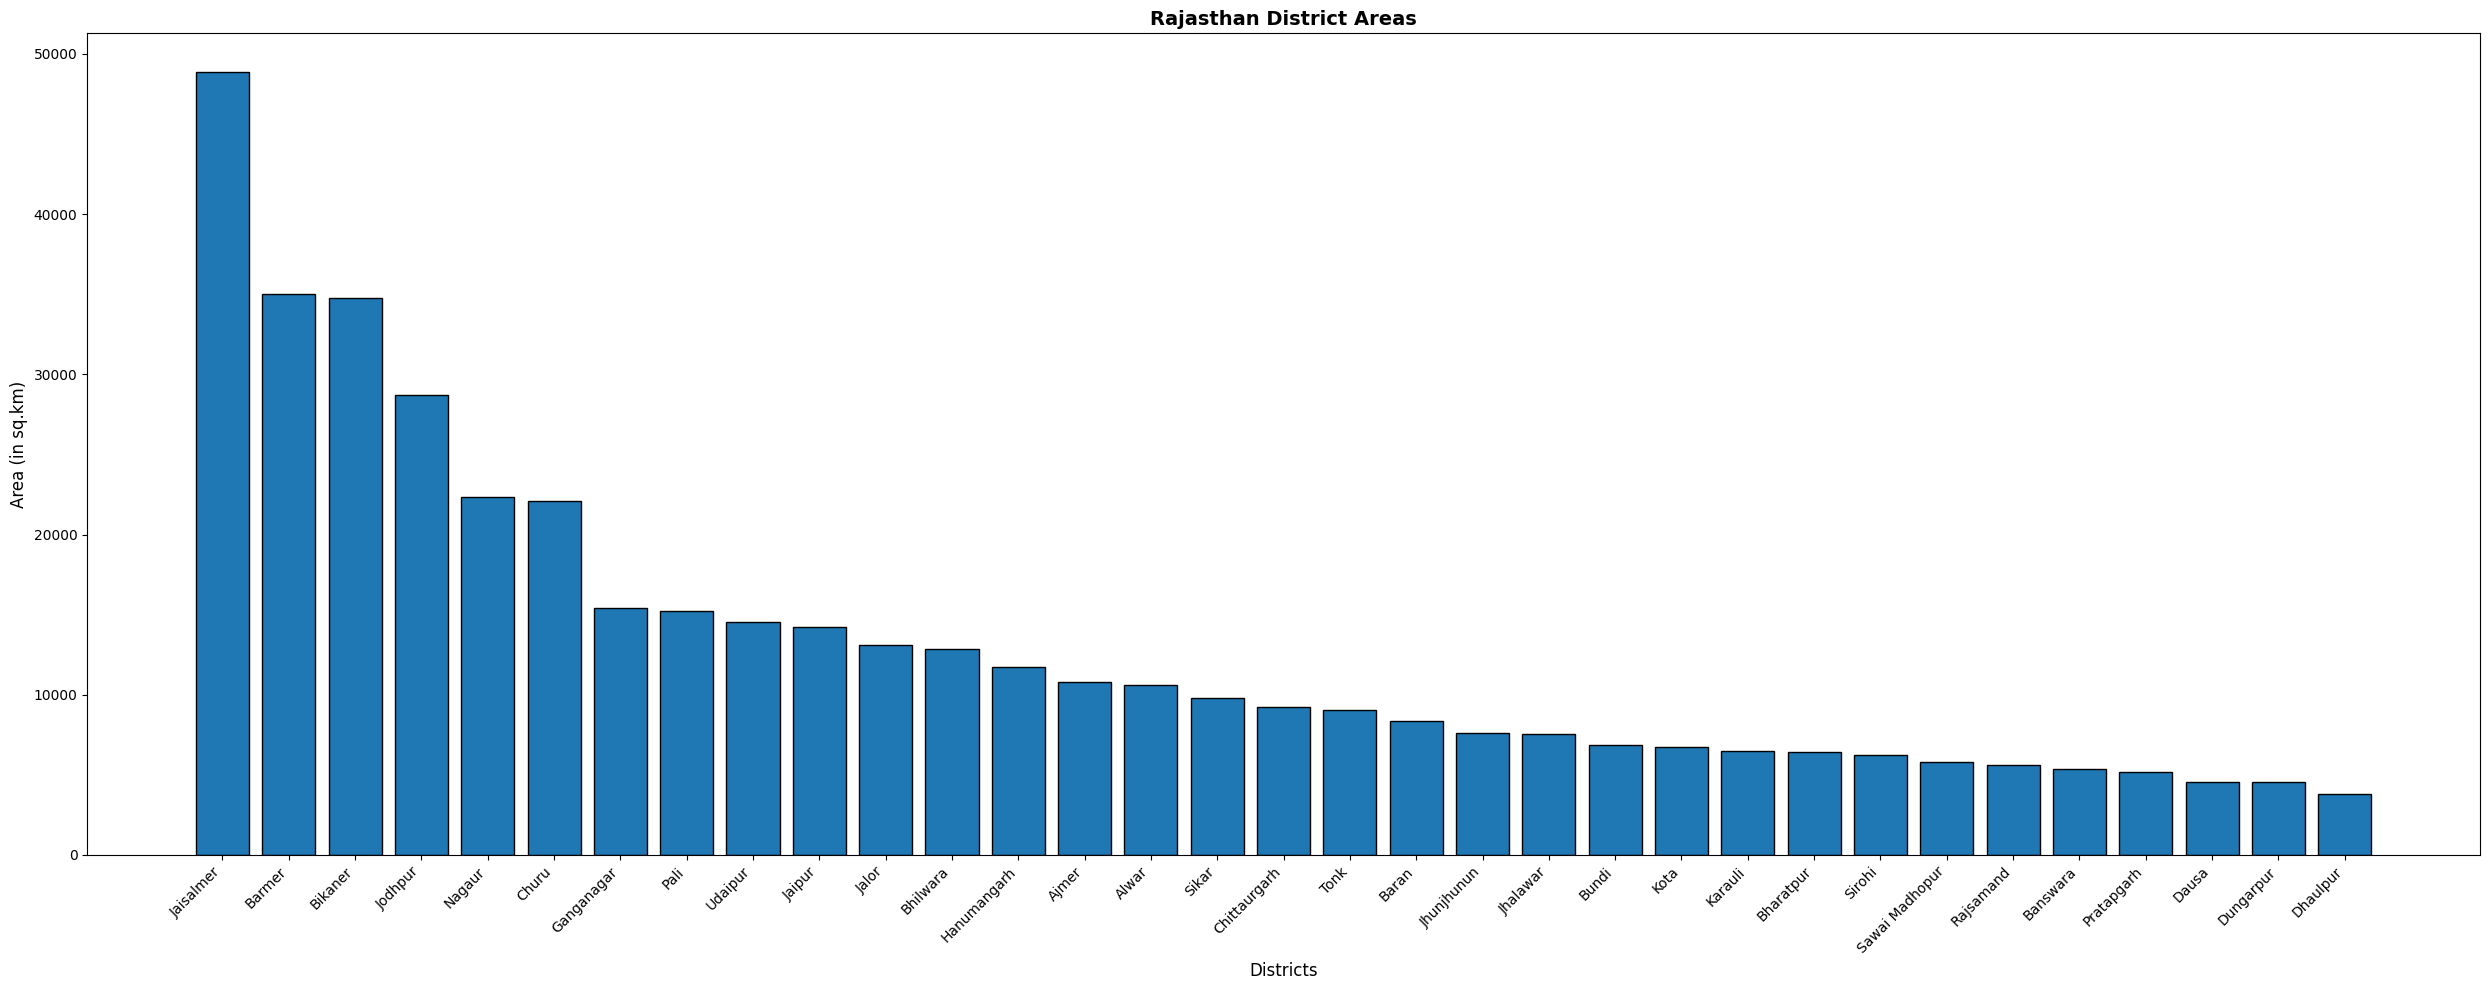

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,Area (in sq.km)
495,IND.29.18_1,IND,India,IND.29_1,Rajasthan,NA,Jaisalmer,NA,NA,District,District,NA,IN.RJ.JS,"POLYGON ((7950500.677 3058696.128, 7949221.631...",48842.537276
482,IND.29.5_1,IND,India,IND.29_1,Rajasthan,NA,Barmer,NA,NA,District,District,NA,IN.RJ.BM,"POLYGON ((7922797.094 2832674.889, 7922791.165...",35042.498945
485,IND.29.8_1,IND,India,IND.29_1,Rajasthan,NA,Bikaner,NA,NA,District,District,NA,IN.RJ.BI,"POLYGON ((8202529.696 3239446.942, 8202364.082...",34792.441616
499,IND.29.22_1,IND,India,IND.29_1,Rajasthan,NA,Jodhpur,NA,NA,District,District,NA,IN.RJ.JO,"POLYGON ((8095249.477 2988912.289, 8093189.924...",28711.342988
502,IND.29.25_1,IND,India,IND.29_1,Rajasthan,NA,Nagaur,NA,NA,District,District,NA,IN.RJ.NA,"POLYGON ((8285055.358 3059693.162, 8282427.623...",22343.098439
488,IND.29.11_1,IND,India,IND.29_1,Rajasthan,NA,Churu,NA,NA,District,District,NA,IN.RJ.CR,"POLYGON ((8221438.518 3193780.567, 8221465.696...",22073.032719
492,IND.29.15_1,IND,India,IND.29_1,Rajasthan,NA,Ganganagar,Sri Ganganagar,NA,District,District,NA,IN.RJ.GA,"POLYGON ((8138668.257 3345716.302, 8137738.273...",15425.388678
503,IND.29.26_1,IND,India,IND.29_1,Rajasthan,NA,Pali,NA,NA,District,District,NA,IN.RJ.PA,"POLYGON ((8122557.03 2905819.469, 8123134.555 ...",15244.545527
510,IND.29.33_1,IND,India,IND.29_1,Rajasthan,NA,Udaipur,NA,NA,District,District,NA,IN.RJ.UP,"POLYGON ((8272228.375 2747768.553, 8271947.257...",14536.625766
494,IND.29.17_1,IND,India,IND.29_1,Rajasthan,NA,Jaipur,Jeipur,NA,District,District,NA,IN.RJ.JP,"POLYGON ((8435384.911 3067142.88, 8434541.556 ...",14216.305319


In [163]:
# Step 7 #
data_shp = gpd.read_file('/Users/snavil/PycharmProjects/Programming Geoinformatics/Session_5/gadm41_IND_shp/gadm41_IND_2.shp')
data_state_shp = data_shp[data_shp['NAME_1'] == 'Rajasthan']

dist_proj = gpd.GeoSeries([Point(1,1), Point(2,2), Point(3,3)], crs=4326)
dist_reproj = data_state_shp.to_crs(epsg=3857)
dist_reproj['Area (in sq.km)'] = dist_reproj.geometry.area / 10**6
dist_reproj.sort_values(by='Area (in sq.km)', ascending=False, inplace=True)

plt.figure(figsize=(25, 10))
plt.bar(dist_reproj["NAME_2"], dist_reproj["Area (in sq.km)"], edgecolor="black")
plt.title("Rajasthan District Areas", fontsize=14, fontweight="bold")
plt.xlabel("Districts", fontsize=12)
plt.ylabel("Area (in sq.km)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
dist_reproj